In [1]:
# ── Imports + Load Best Model ────────────────────────
import warnings, os
warnings.filterwarnings("ignore")

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
import shap
import joblib

from sklearn.metrics         import (classification_report, confusion_matrix,
                                    ConfusionMatrixDisplay, f1_score,
                                    accuracy_score, roc_auc_score,
                                    RocCurveDisplay, roc_curve)
from sklearn.preprocessing   import label_binarize, LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

EMOTIONS = ["angry", "happy", "neutral", "sad", "surprise"]
SEED     = 42
os.makedirs("output/04_evaluate", exist_ok=True)

# Load artefacts from Phase 3
best_model = joblib.load("output_model/best_model_F41.pkl")
scaler     = joblib.load("output_model/scaler_F41.pkl")
le         = joblib.load("output_model/label_encoder_F41.pkl")

print(f"Model loaded : {type(best_model).__name__}")
print(f"Scaler loaded: {type(scaler).__name__}")
print(f"Classes      : {list(le.classes_)}")

Model loaded : RandomForestClassifier
Scaler loaded: StandardScaler
Classes      : [np.str_('angry'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprise')]


In [2]:
# ── Load Data + Predict ──────────────────────────────
TRAIN_CSV = "csv/features_train_F41.csv"
TEST_CSV  = "csv/features_test_F41.csv"

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

FEATURE_NAMES = [c for c in df_train.columns if c != "label"]

X_train = scaler.transform(df_train[FEATURE_NAMES].values)
y_train = le.transform(df_train["label"].values)
X_test  = scaler.transform(df_test[FEATURE_NAMES].values)
y_test  = le.transform(df_test["label"].values)

y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)   # (n, 5)

acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test set     : {X_test.shape}")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro-F1     : {macro_f1:.4f}")
print(f"\nPer-class F1:")
rpt = classification_report(y_test, y_pred,
                            target_names=EMOTIONS, output_dict=True)
for emo in EMOTIONS:
    f1  = rpt[emo]["f1-score"]
    bar = "█" * int(f1 * 20)
    flag = "(Bad)" if f1 < 0.55 else "(Good)"
    print(f"  {flag} {emo:<10}: {f1:.4f}  {bar}")

Test set     : (6043, 41)
Accuracy     : 0.6252
Macro-F1     : 0.6144

Per-class F1:
  (Bad) angry     : 0.4925  █████████
  (Good) happy     : 0.7858  ███████████████
  (Good) neutral   : 0.5556  ███████████
  (Bad) sad       : 0.5011  ██████████
  (Good) surprise  : 0.7372  ██████████████


In [3]:
# ── Full Classification Report ───────────────────────
print("=" * 62)
print("Classification Report — Random Forest (F41, Test Set)")
print("=" * 62)
print(classification_report(y_test, y_pred,
                            target_names=EMOTIONS, digits=4))

# Precision / Recall / F1 table as DataFrame
rpt_df = pd.DataFrame(rpt).T.round(4)
rpt_df = rpt_df.loc[EMOTIONS + ["macro avg", "weighted avg"]]
rpt_df.to_csv("output/04_evaluate/classification_report_F41.csv")
print("Saved: output/04_evaluate/classification_report_F41.csv")

Classification Report — Random Forest (F41, Test Set)
              precision    recall  f1-score   support

       angry     0.5254    0.4635    0.4925       958
       happy     0.8269    0.7486    0.7858      1774
     neutral     0.4840    0.6521    0.5556      1233
         sad     0.5377    0.4691    0.5011      1247
    surprise     0.7319    0.7425    0.7372       831

    accuracy                         0.6252      6043
   macro avg     0.6212    0.6151    0.6144      6043
weighted avg     0.6364    0.6252    0.6269      6043

Saved: output/04_evaluate/classification_report_F41.csv


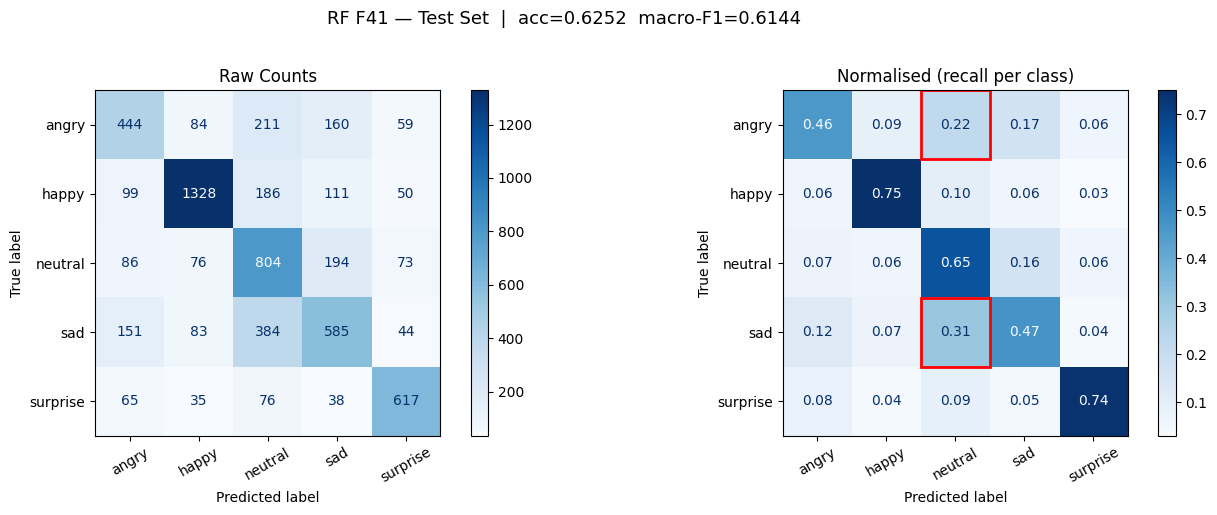

Saved: output/04_evaluate/confusion_matrix_F41.png
(Red boxes = confusion pairs > 20%)


In [4]:
# ── Confusion Matrix (raw + normalised) ──────────────
cm      = confusion_matrix(y_test, y_pred,
                            labels=list(range(len(EMOTIONS))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=EMOTIONS).plot(
    ax=axes[0], colorbar=True, cmap="Blues", values_format="d")
axes[0].set_title("Raw Counts", fontsize=12)
axes[0].tick_params(axis="x", rotation=30)

ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=EMOTIONS).plot(
    ax=axes[1], colorbar=True, cmap="Blues", values_format=".2f")
axes[1].set_title("Normalised (recall per class)", fontsize=12)
axes[1].tick_params(axis="x", rotation=30)

# Annotate worst confusion pairs
for i in range(len(EMOTIONS)):
    for j in range(len(EMOTIONS)):
        if i != j and cm_norm[i, j] > 0.20:
            axes[1].add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                fill=False, edgecolor="red", lw=2))

plt.suptitle(f"RF F41 — Test Set  |  acc={acc:.4f}  macro-F1={macro_f1:.4f}",
            fontsize=13, y=1.02)
plt.tight_layout()
p = "output/04_evaluate/confusion_matrix_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")
print("(Red boxes = confusion pairs > 20%)")

Computing SHAP values (TreeExplainer) …
shap_values type  : <class 'numpy.ndarray'>
shap_values shape : (600, 41, 5)
mean_shap shape   : (41,)  (expected (41,))


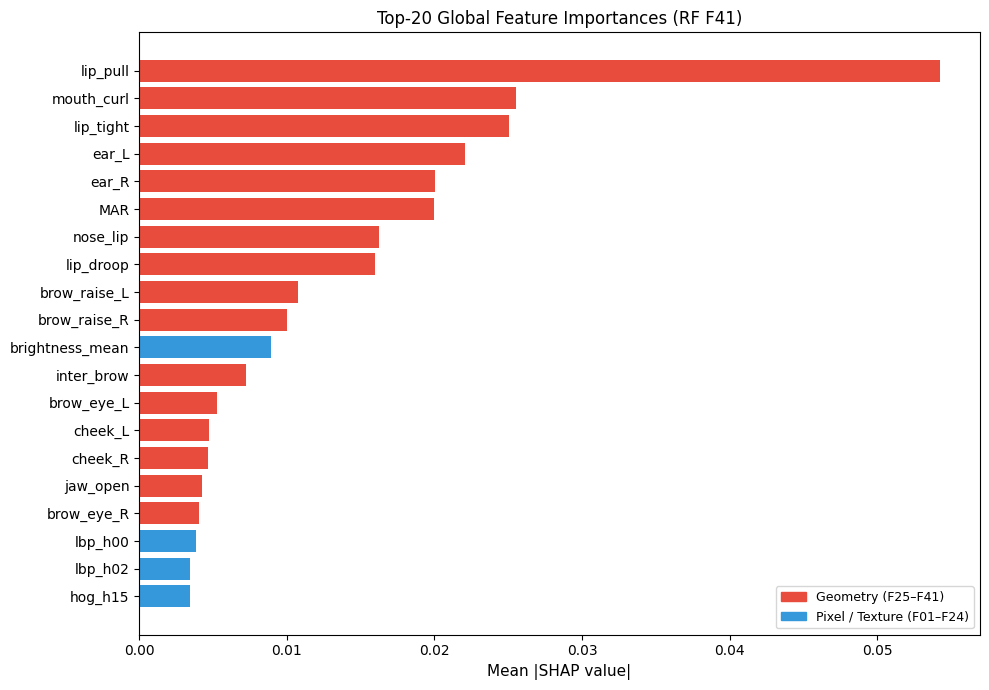


Top-10 features:
     feature  mean_abs_shap
    lip_pull       0.054238
  mouth_curl       0.025499
   lip_tight       0.025049
       ear_L       0.022079
       ear_R       0.020008
         MAR       0.019948
    nose_lip       0.016251
   lip_droop       0.015974
brow_raise_L       0.010782
brow_raise_R       0.010025
Saved: output/04_evaluate/shap_global_F41.png


In [5]:
# ── SHAP Global Feature Importance ───────────────────
rng     = np.random.default_rng(SEED)
idx_sub = rng.choice(len(X_test), size=min(600, len(X_test)), replace=False)
X_sub   = X_test[idx_sub]

print("Computing SHAP values (TreeExplainer) …")
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sub)

# ── Handle both old API (list) and new API (3D array) ────────
if isinstance(shap_values, list):
    # Old SHAP: list[n_classes], each (n_samples, n_features)
    mean_shap = np.mean([np.abs(sv).mean(axis=0)
                         for sv in shap_values], axis=0)
    shap_vals_list = shap_values                    # keep for beeswarms
else:
    # New SHAP: ndarray (n_samples, n_features, n_classes)
    #       or: ndarray (n_classes, n_samples, n_features)
    if shap_values.ndim == 3:
        if shap_values.shape[2] == len(EMOTIONS):
            # shape: (n_samples, n_features, n_classes)
            mean_shap      = np.abs(shap_values).mean(axis=(0, 2))
            shap_vals_list = [shap_values[:, :, i]
                              for i in range(len(EMOTIONS))]
        else:
            # shape: (n_classes, n_samples, n_features)
            mean_shap      = np.abs(shap_values).mean(axis=(0, 1))
            shap_vals_list = [shap_values[i]
                        for i in range(len(EMOTIONS))]
    else:
        # Binary / unexpected — fallback
        mean_shap      = np.abs(shap_values).mean(axis=0)
        shap_vals_list = [shap_values]

print(f"shap_values type  : {type(shap_values)}")
print(f"shap_values shape : {np.array(shap_values).shape}")
print(f"mean_shap shape   : {mean_shap.shape}  (expected ({len(FEATURE_NAMES)},))")

shap_df = (pd.DataFrame({"feature": FEATURE_NAMES,
                        "mean_abs_shap": mean_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True))
shap_df.to_csv("output/04_evaluate/shap_importances_F41.csv", index=False)

GEO_FEATS = {"ear_L","ear_R","brow_eye_L","brow_eye_R","inter_brow",
        "brow_raise_L","brow_raise_R","MAR","lip_pull","lip_droop",
        "mouth_curl","lip_tight","jaw_open","cheek_L","cheek_R",
        "nose_lip","face_AR"}

top20   = shap_df.head(20)
colours = ["#e74c3c" if f in GEO_FEATS else "#3498db"
        for f in top20["feature"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20["feature"][::-1], top20["mean_abs_shap"][::-1],
        color=colours[::-1])
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title("Top-20 Global Feature Importances (RF F41)", fontsize=12)
handles = [mpatches.Patch(color="#e74c3c", label="Geometry (F25–F41)"),
        mpatches.Patch(color="#3498db", label="Pixel / Texture (F01–F24)")]
ax.legend(handles=handles, fontsize=9)
plt.tight_layout()
p = "output/04_evaluate/shap_global_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop-10 features:")
print(shap_df.head(10)[["feature","mean_abs_shap"]].to_string(index=False))
print(f"Saved: {p}")

In [6]:
# ── SHAP Beeswarm — Per Class ───────────────────────
for emo in EMOTIONS:
    idx = int(le.transform([emo])[0])
    plt.figure(figsize=(9, 6))
    shap.summary_plot(shap_vals_list[idx], X_sub,      # ← shap_vals_list
                      feature_names=FEATURE_NAMES,
                      max_display=15, show=False, plot_type="dot")
    plt.title(f"SHAP Beeswarm — class: {emo}  "
              f"(F1={rpt[emo]['f1-score']:.4f})", fontsize=11)
    plt.tight_layout()
    p = f"output/04_evaluate/shap_beeswarm_{emo}_F41.png"
    plt.savefig(p, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved: {p}")

Saved: output/04_evaluate/shap_beeswarm_angry_F41.png
Saved: output/04_evaluate/shap_beeswarm_happy_F41.png
Saved: output/04_evaluate/shap_beeswarm_neutral_F41.png
Saved: output/04_evaluate/shap_beeswarm_sad_F41.png
Saved: output/04_evaluate/shap_beeswarm_surprise_F41.png


In [7]:
# ── Error Analysis ────────────────────────────────────
df_errors = pd.DataFrame({
    "true_label" : le.inverse_transform(y_test),
    "pred_label" : le.inverse_transform(y_pred),
    "correct"    : (y_test == y_pred),
})
for feat in FEATURE_NAMES:
    df_errors[feat] = df_test[feat].values

# Confusion pair counts
print("Top confusion pairs (true → predicted):")
pairs = (df_errors[~df_errors["correct"]]
        .groupby(["true_label","pred_label"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False))
print(pairs.head(10).to_string(index=False))

# Per-class error rate
print("\nPer-class error rate:")
for emo in EMOTIONS:
    subset   = df_errors[df_errors["true_label"] == emo]
    err_rate = 1 - subset["correct"].mean()
    top_conf = (subset[~subset["correct"]]["pred_label"]
                .value_counts().idxmax()
                if (~subset["correct"]).any() else "—")
    print(f"  {emo:<10}: error={err_rate:.3f}  most confused with → {top_conf}")

# Feature means for correct vs incorrect predictions
print("\nKey geometry features — correct vs. misclassified (global):")
for feat in ["MAR","ear_L","brow_eye_L","inter_brow","jaw_open"]:
    mu_ok  = df_errors.loc[ df_errors["correct"], feat].mean()
    mu_err = df_errors.loc[~df_errors["correct"], feat].mean()
    print(f"  {feat:<18}: correct={mu_ok:.4f}  wrong={mu_err:.4f}  "
        f"diff={mu_err-mu_ok:+.4f}")

Top confusion pairs (true → predicted):
true_label pred_label  count
       sad    neutral    384
     angry    neutral    211
   neutral        sad    194
     happy    neutral    186
     angry        sad    160
       sad      angry    151
     happy        sad    111
     happy      angry     99
   neutral      angry     86
     angry      happy     84

Per-class error rate:
  angry     : error=0.537  most confused with → neutral
  happy     : error=0.251  most confused with → neutral
  neutral   : error=0.348  most confused with → sad
  sad       : error=0.531  most confused with → neutral
  surprise  : error=0.258  most confused with → neutral

Key geometry features — correct vs. misclassified (global):
  MAR               : correct=0.1821  wrong=0.1300  diff=-0.0520
  ear_L             : correct=0.2888  wrong=0.2891  diff=+0.0002
  brow_eye_L        : correct=-0.1310  wrong=-0.1272  diff=+0.0039
  inter_brow        : correct=0.2996  wrong=0.2989  diff=-0.0007
  jaw_open         

5-Fold Cross-Validation (train set, pre-SMOTE):
  Accuracy : 0.6229 ± 0.0116
  Macro-F1 : 0.6069 ± 0.0118

Per-fold:
  Fold 1: acc=0.6063  F1=0.5919
  Fold 2: acc=0.6335  F1=0.6162
  Fold 3: acc=0.6132  F1=0.5952
  Fold 4: acc=0.6250  F1=0.6088
  Fold 5: acc=0.6364  F1=0.6226

Test set (Phase 3):  acc=0.6252  F1=0.6144


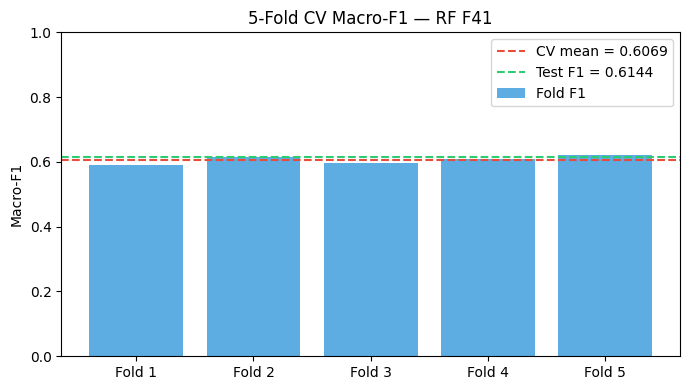

Saved: output/04_evaluate/cv_f1_F41.png


In [8]:
# ── 5-Fold Cross-Validation on Train Set ─────────────
from imblearn.pipeline       import Pipeline as ImbPipeline
from imblearn.over_sampling  import SMOTE
from sklearn.preprocessing   import StandardScaler

cv_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  SMOTE(random_state=SEED, k_neighbors=5)),
    ("clf",    best_model),
])

y_raw = le.transform(df_train["label"].values)
X_raw = df_train[FEATURE_NAMES].values

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_res  = cross_validate(
    best_model, X_train, y_train,
    cv      = cv,
    scoring = {"accuracy": "accuracy", "f1_macro": "f1_macro"},
    n_jobs  = -1,
    verbose = 0,
)

fold_acc = cv_res["test_accuracy"]
fold_f1  = cv_res["test_f1_macro"]

print("5-Fold Cross-Validation (train set, pre-SMOTE):")
print(f"  Accuracy : {fold_acc.mean():.4f} ± {fold_acc.std():.4f}")
print(f"  Macro-F1 : {fold_f1.mean():.4f} ± {fold_f1.std():.4f}")
print(f"\nPer-fold:")
for i, (a, f) in enumerate(zip(fold_acc, fold_f1), 1):
    print(f"  Fold {i}: acc={a:.4f}  F1={f:.4f}")
print(f"\nTest set (Phase 3):  acc={acc:.4f}  F1={macro_f1:.4f}")

# Plot fold F1
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), fold_f1, color="#3498db", alpha=0.8, label="Fold F1")
ax.axhline(fold_f1.mean(), color="#e74c3c", ls="--",
        label=f"CV mean = {fold_f1.mean():.4f}")
ax.axhline(macro_f1, color="#2ecc71", ls="--",
        label=f"Test F1 = {macro_f1:.4f}")
ax.set_xticks(range(1, 6))
ax.set_xticklabels([f"Fold {i}" for i in range(1, 6)])
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.set_title("5-Fold CV Macro-F1 — RF F41", fontsize=12)
ax.legend()
plt.tight_layout()
p = "output/04_evaluate/cv_f1_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

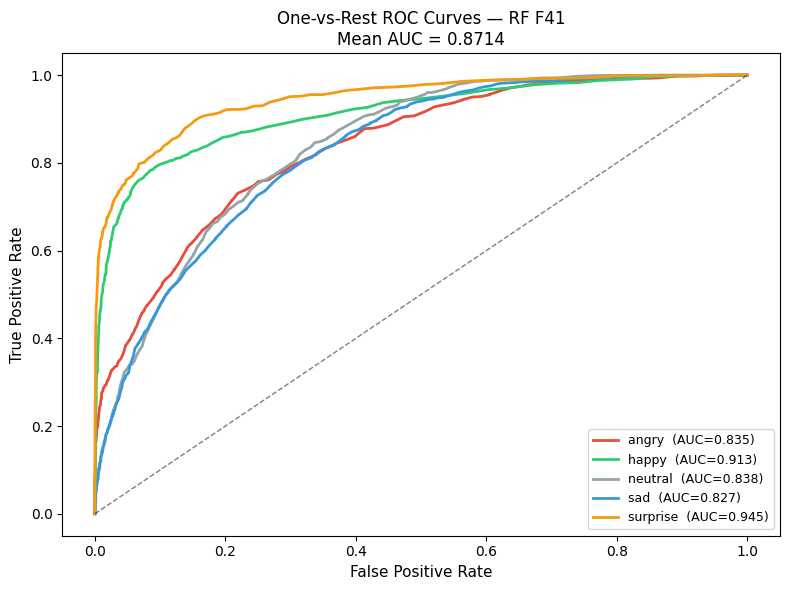

AUC per class:
  angry     : 0.8354
  happy     : 0.9127
  neutral   : 0.8376
  sad       : 0.8267
  surprise  : 0.9448
  Mean      : 0.8714
Saved: output/04_evaluate/roc_curves_F41.png


In [9]:
# ── One-vs-Rest ROC Curves ───────────────────────────
y_bin = label_binarize(y_test, classes=list(range(len(EMOTIONS))))

COLORS_ROC = ["#e74c3c","#2ecc71","#95a5a6","#3498db","#f39c12"]
fig, ax = plt.subplots(figsize=(8, 6))

aucs = []
for i, (emo, col) in enumerate(zip(EMOTIONS, COLORS_ROC)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
    auc_val     = roc_auc_score(y_bin[:, i], y_pred_prob[:, i])
    aucs.append(auc_val)
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f"{emo}  (AUC={auc_val:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title(f"One-vs-Rest ROC Curves — RF F41\n"
            f"Mean AUC = {np.mean(aucs):.4f}", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
p = "output/04_evaluate/roc_curves_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print("AUC per class:")
for emo, auc in zip(EMOTIONS, aucs):
    print(f"  {emo:<10}: {auc:.4f}")
print(f"  {'Mean':<10}: {np.mean(aucs):.4f}")
print(f"Saved: {p}")

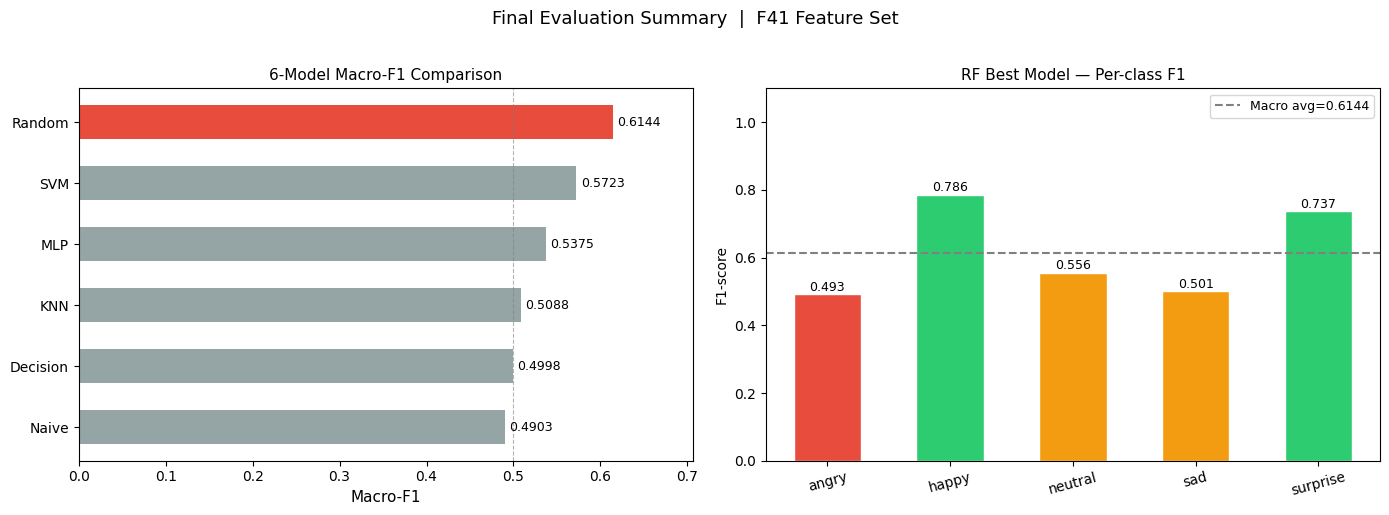


══════════════════════════════════════════════════════════════
Final Results — F41 (41 features, 5 emotions)
══════════════════════════════════════════════════════════════
 Best model   : Random Forest
 Test accuracy: 0.6252
 Macro-F1     : 0.6144
 Mean AUC     : 0.8714
 CV F1        : 0.6069 ± 0.0118
──────────────────────────────────────────────────────────────
 Per-class F1:
   angry       P=0.5254  R=0.4635  F1=0.4925
   happy       P=0.8269  R=0.7486  F1=0.7858
   neutral     P=0.4840  R=0.6521  F1=0.5556
   sad         P=0.5377  R=0.4691  F1=0.5011
   surprise    P=0.7319  R=0.7425  F1=0.7372
══════════════════════════════════════════════════════════════

All output/04_evaluate artefacts:
  output/04_evaluateclassification_report_F41.csv                          0.3 KB
  output/04_evaluateconfusion_matrix_F41.png                             105.5 KB
  output/04_evaluatecv_f1_F41.png                                         27.4 KB
  output/04_evaluateroc_curves_F41.png           

In [12]:
# ── Final Report Summary ────────────────────────────
df_cmp = pd.read_csv("output/03_train/model_comparison_F41.csv", index_col=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: 6-model macro-F1 bar ──────────────────────────────
models_short = [m.split("\n")[0] if "\n" in m else m.split(" ")[0]
                for m in df_cmp.index]
f1s    = df_cmp["Macro-F1"].values
colors = ["#e74c3c" if m == df_cmp["Macro-F1"].idxmax()
        else "#95a5a6" for m in df_cmp.index]

axes[0].barh(models_short[::-1], f1s[::-1], color=colors[::-1], height=0.55)
for i, (m, v) in enumerate(zip(models_short[::-1], f1s[::-1])):
    axes[0].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)
axes[0].set_xlabel("Macro-F1", fontsize=11)
axes[0].set_xlim(0, max(f1s) * 1.15)
axes[0].set_title("6-Model Macro-F1 Comparison", fontsize=11)
axes[0].axvline(0.5, color="grey", ls="--", lw=0.8, alpha=0.6)

# ── Right: RF per-class F1 ───────────────────────────────────
rpt = classification_report(y_test, y_pred,
                            target_names=EMOTIONS, output_dict=True)
pf1 = [rpt[e]["f1-score"] for e in EMOTIONS]
clr = ["#e74c3c" if v < 0.50 else
    "#f39c12" if v < 0.65 else "#2ecc71" for v in pf1]
bars = axes[1].bar(EMOTIONS, pf1, color=clr, width=0.55, edgecolor="white")
axes[1].axhline(macro_f1, color="grey", ls="--",
                label=f"Macro avg={macro_f1:.4f}")
for bar, v in zip(bars, pf1):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f"{v:.3f}", ha="center", fontsize=9)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("F1-score")
axes[1].set_title("RF Best Model — Per-class F1", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Final Evaluation Summary  |  F41 Feature Set",
            fontsize=13, y=1.02)
plt.tight_layout()
p = "output/04_final_summary_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()

# ── Print final table ────────────────────────────────────────
print("\n" + "═"*62)
print("Final Results — F41 (41 features, 5 emotions)")
print("═"*62)
print(f" Best model   : Random Forest")
print(f" Test accuracy: {acc:.4f}")
print(f" Macro-F1     : {macro_f1:.4f}")
print(f" Mean AUC     : {np.mean(aucs):.4f}")
print(f" CV F1        : {fold_f1.mean():.4f} ± {fold_f1.std():.4f}")
print("─"*62)
print(" Per-class F1:")
for emo in EMOTIONS:
    f = rpt[emo]["f1-score"]
    p_val = rpt[emo]["precision"]
    r_val = rpt[emo]["recall"]
    print(f"   {emo:<10}  P={p_val:.4f}  R={r_val:.4f}  F1={f:.4f}")
print("═"*62)
print("\nAll output/04_evaluate artefacts:")
for f in sorted(os.listdir("output/04_evaluate")):
    if "F41" in f:
        kb = os.path.getsize(f"output/04_evaluate/{f}") / 1024
        print(f"  output/04_evaluate{f:<50} {kb:>7.1f} KB")